In [102]:
import deuces
import numpy as np
from deuces import Card, Evaluator, Deck

In [103]:
NUM_SIMS = 1000
EVALUATOR = Evaluator()

def getWinLoss(hero:list, villain:list, board:list) -> int:
    """
    Returns 1 if hand1 wins, -100 if hand2 wins, 0 if tie
    """
    hero_score = EVALUATOR.evaluate(board, hero)
    villain_score = EVALUATOR.evaluate(board, villain)
    if hero_score < villain_score:
        return 1
    elif hero_score > villain_score:
        return -1
    else:
        return 0

In [104]:
deck = np.sort(Deck().cards)
Card.print_pretty_cards(deck)
deck = np.delete(deck, [-3,-4,-5,-6]) # remove As, Ah, Kc, Kd
HERO = np.array([Card.new("As"), Card.new("Ah")])
VILLAIN = np.array([Card.new("Kc"), Card.new("Kd")])
print("Hero: ",end=""); Card.print_pretty_cards(HERO)
print("Villain: ",end=""); Card.print_pretty_cards(VILLAIN)
Card.print_pretty_cards(deck)

  [ 2 ♠ ] , [ 2 ❤ ] , [ 2 ♣ ] , [ 2 ♦ ] , [ 3 ♠ ] , [ 3 ❤ ] , [ 3 ♣ ] , [ 3 ♦ ] , [ 4 ♠ ] , [ 4 ❤ ] , [ 4 ♣ ] , [ 4 ♦ ] , [ 5 ♠ ] , [ 5 ❤ ] , [ 5 ♣ ] , [ 5 ♦ ] , [ 6 ♠ ] , [ 6 ❤ ] , [ 6 ♣ ] , [ 6 ♦ ] , [ 7 ♠ ] , [ 7 ❤ ] , [ 7 ♣ ] , [ 7 ♦ ] , [ 8 ♠ ] , [ 8 ❤ ] , [ 8 ♣ ] , [ 8 ♦ ] , [ 9 ♠ ] , [ 9 ❤ ] , [ 9 ♣ ] , [ 9 ♦ ] , [ T ♠ ] , [ T ❤ ] , [ T ♣ ] , [ T ♦ ] , [ J ♠ ] , [ J ❤ ] , [ J ♣ ] , [ J ♦ ] , [ Q ♠ ] , [ Q ❤ ] , [ Q ♣ ] , [ Q ♦ ] , [ K ♠ ] , [ K ❤ ] , [ K ♣ ] , [ K ♦ ] , [ A ♠ ] , [ A ❤ ] , [ A ♣ ] , [ A ♦ ]  
Hero:   [ A ♠ ] , [ A ❤ ]  
Villain:   [ K ♦ ] , [ K ♣ ]  
  [ 2 ♠ ] , [ 2 ❤ ] , [ 2 ♣ ] , [ 2 ♦ ] , [ 3 ♠ ] , [ 3 ❤ ] , [ 3 ♣ ] , [ 3 ♦ ] , [ 4 ♠ ] , [ 4 ❤ ] , [ 4 ♣ ] , [ 4 ♦ ] , [ 5 ♠ ] , [ 5 ❤ ] , [ 5 ♣ ] , [ 5 ♦ ] , [ 6 ♠ ] , [ 6 ❤ ] , [ 6 ♣ ] , [ 6 ♦ ] , [ 7 ♠ ] , [ 7 ❤ ] , [ 7 ♣ ] , [ 7 ♦ ] , [ 8 ♠ ] , [ 8 ❤ ] , [ 8 ♣ ] , [ 8 ♦ ] , [ 9 ♠ ] , [ 9 ❤ ] , [ 9 ♣ ] , [ 9 ♦ ] , [ T ♠ ] , [ T ❤ ] , [ T ♣ ] , [ T ♦ ] , [ J ♠ ] , [ J ❤ ] , [ J ♣ ] , [ J ♦ ] , [ Q ♠ ] , [ Q ❤ ]

In [105]:
# run it once
results_runitonce = np.zeros(NUM_SIMS)
for i in range(NUM_SIMS):
    np.random.shuffle(deck)
    board = deck[:5]
    result = getWinLoss(HERO, VILLAIN, board)*100
    results_runitonce[i] += result

# print results and statistics like mean and stdev
print("Results (Run It Once):")
print("Mean:", np.mean(results_runitonce))
print("Standard Deviation:", np.std(results_runitonce))

# trend_runitonce = np.cumsum(results_runitonce)
# this line will be used for trend visualization later on

Results (Run It Once):
Mean: 62.8
Standard Deviation: 77.43487586352805


In [106]:
# run it twice WITH reshuffle
results_runittwice_withreshuffle = np.zeros(NUM_SIMS)
for i in range(NUM_SIMS):
    np.random.shuffle(deck)
    board1 = deck[:5]
    result1 = getWinLoss(HERO, VILLAIN, board1)*100/2
    np.random.shuffle(deck)
    board2 = deck[:5]
    result2 = getWinLoss(HERO, VILLAIN, board2)*100/2
    results_runittwice_withreshuffle[i] += result1 + result2
# print results and statistics like mean and stdev
print("Results (Run It Twice with Reshuffle):")
print("Mean:", np.mean(results_runittwice_withreshuffle))
print("Standard Deviation:", np.std(results_runittwice_withreshuffle))
# trend_runittwice_withreshuffle = np.cumsum(results_runittwice_withreshuffle)
# this line will be used for trend visualization later on

Results (Run It Twice with Reshuffle):
Mean: 63.7
Standard Deviation: 55.92235688881505


In [107]:
# run it twice normally
results_runittwice = np.zeros(NUM_SIMS)
for i in range(NUM_SIMS):
    np.random.shuffle(deck)
    board1 = deck[:5]
    board2 = deck[5:10]
    result1 = getWinLoss(HERO, VILLAIN, board1)*100/2
    result2 = getWinLoss(HERO, VILLAIN, board2)*100/2
    results_runittwice[i] += result1 + result2
    
# print results and statistics like mean and stdev
print("Results (Run It Twice):")
print("Mean:", np.mean(results_runittwice))
print("Standard Deviation:", np.std(results_runittwice))

# trend_runittwice = np.cumsum(results_runittwice)
# this line will be used for trend visualization later on

Results (Run It Twice):
Mean: 61.75
Standard Deviation: 53.47370849305292


In [108]:
# run it three times
results_runitthreetimes = np.zeros(NUM_SIMS)
for i in range(NUM_SIMS):
    np.random.shuffle(deck)
    board1 = deck[:5]
    board2 = deck[5:10]
    board3 = deck[10:15]
    result1 = getWinLoss(HERO, VILLAIN, board1)*100/3
    result2 = getWinLoss(HERO, VILLAIN, board2)*100/3
    result3 = getWinLoss(HERO, VILLAIN, board3)*100/3
    results_runitthreetimes[i] += result1 + result2 + result3
    
# print results and statistics like mean and stdev
print("Results (Run It Three Times):")
print("Mean:", np.mean(results_runitthreetimes))
print("Standard Deviation:", np.std(results_runitthreetimes))

# trend_runitthreetimes = np.cumsum(results_runitthreetimes)
# this line will be used for trend visualization later on

Results (Run It Three Times):
Mean: 61.866666666666674
Standard Deviation: 41.0861425679159


Text(0.5, 1.0, 'Win/Loss Trend Comparison')

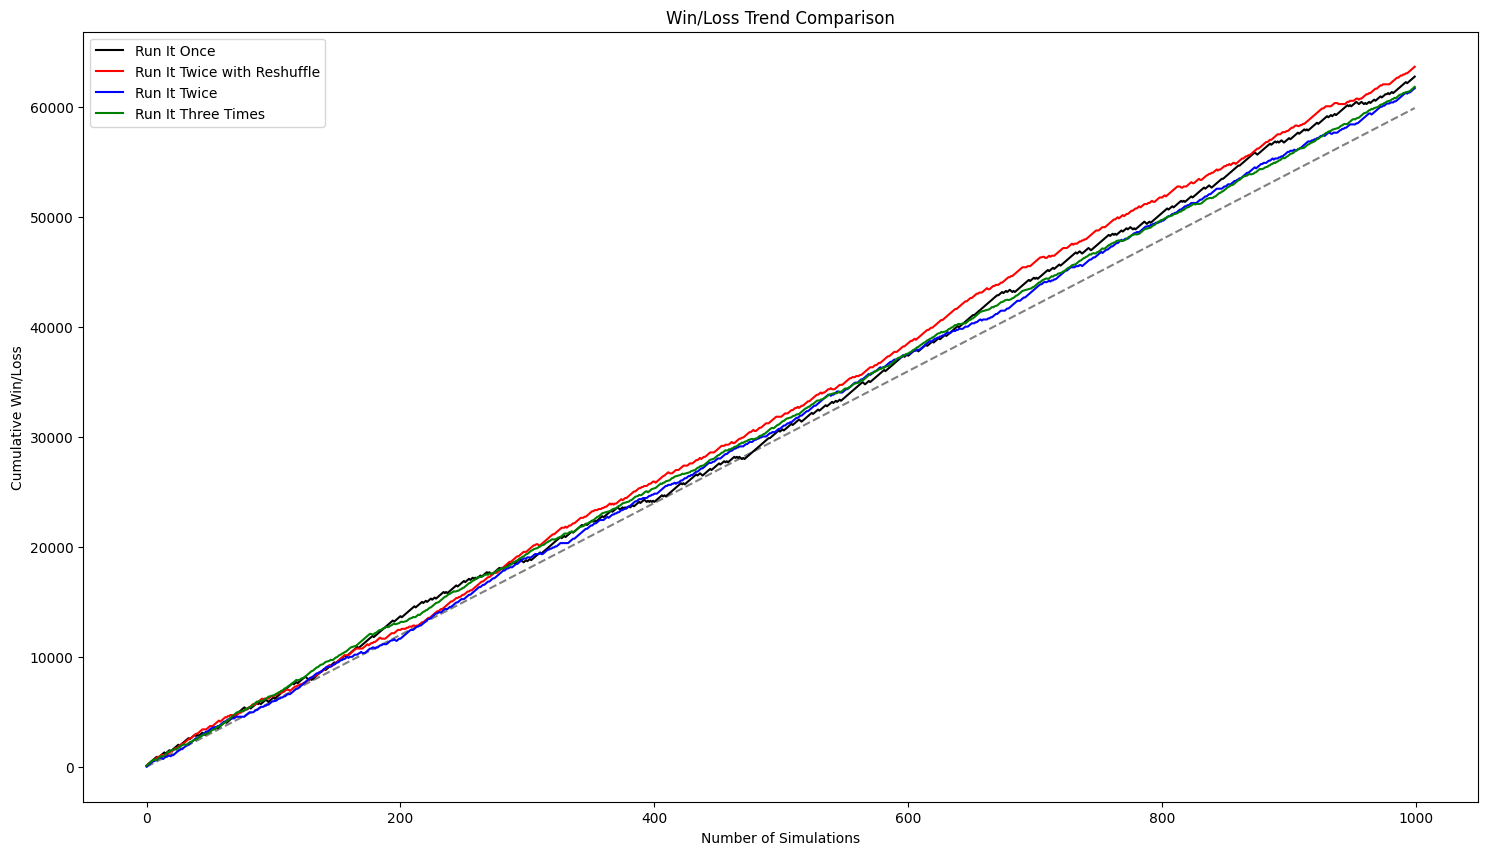

In [109]:
# data visualization
import matplotlib.pyplot as plt

# plot the win/loss trend for each method
# plot the legends as well
# black: run it once
# red: run it twice with reshuffle
# blue: run it twice
# green: run it three times
plt.figure(figsize=(18, 10))
plt.plot(np.arange(NUM_SIMS)*60, color='gray', linestyle='--') # baseline
plt.plot(np.cumsum(results_runitonce), color='black', label='Run It Once')
plt.plot(np.cumsum(results_runittwice_withreshuffle), color='red', label='Run It Twice with Reshuffle')
plt.plot(np.cumsum(results_runittwice), color='blue', label='Run It Twice')
plt.plot(np.cumsum(results_runitthreetimes), color='green', label='Run It Three Times')
plt.legend()
plt.xlabel('Number of Simulations')
plt.ylabel('Cumulative Win/Loss')
plt.title('Win/Loss Trend Comparison')